cpu
Failed to download (trying next):
HTTP Error 404: Not Found



100.0%


Extracting ./data\MNIST\raw\train-images-idx3-ubyte.gz to ./data\MNIST\raw

Failed to download (trying next):
HTTP Error 404: Not Found



100.0%


Extracting ./data\MNIST\raw\train-labels-idx1-ubyte.gz to ./data\MNIST\raw

Failed to download (trying next):
HTTP Error 404: Not Found



100.0%


Extracting ./data\MNIST\raw\t10k-images-idx3-ubyte.gz to ./data\MNIST\raw

Failed to download (trying next):
HTTP Error 404: Not Found



100.0%


Extracting ./data\MNIST\raw\t10k-labels-idx1-ubyte.gz to ./data\MNIST\raw

Epoch 1 Loss: 0.1144
Epoch 2 Loss: 0.1120
Epoch 3 Loss: 0.1120
Epoch 4 Loss: 0.1120
Epoch 5 Loss: 0.1120


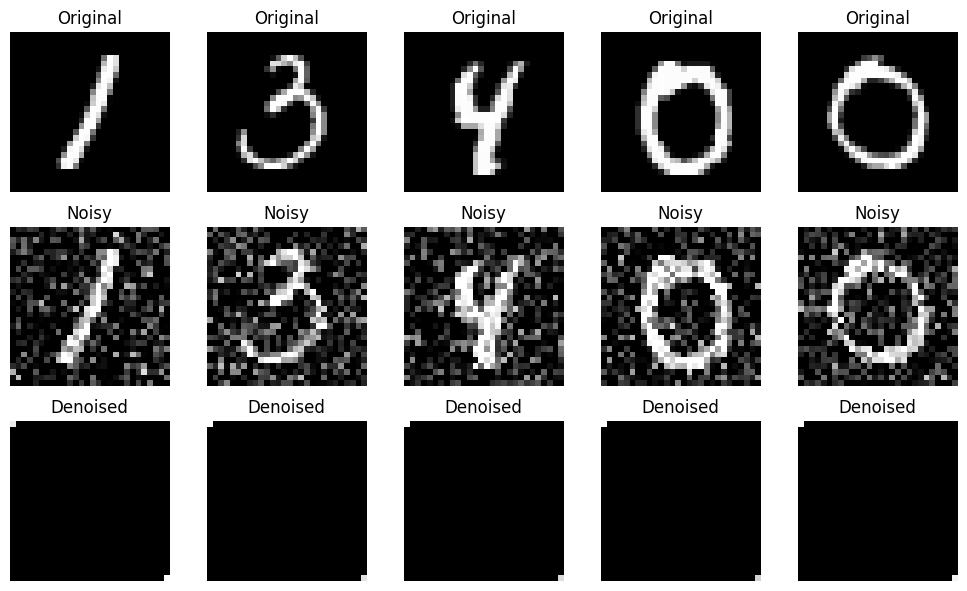

In [1]:
# ============================================
# Neural ODE を用いた簡単な画像ノイズ除去
# PyTorch + torchdiffeq
# ============================================

# 必要ライブラリ
# pip install torch torchvision matplotlib torchdiffeq

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
import matplotlib.pyplot as plt

from torchdiffeq import odeint

# ============================================
# デバイス設定
# ============================================

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

# ============================================
# データセット
# MNISTを使用
# ============================================

transform = transforms.ToTensor()

train_dataset = datasets.MNIST(
    root="./data",
    train=True,
    download=True,
    transform=transform
)

train_loader = DataLoader(
    train_dataset,
    batch_size=64,
    shuffle=True
)

# ============================================
# ノイズ付加関数
# ============================================

def add_noise(x, noise_level=0.3):
    noise = noise_level * torch.randn_like(x)
    noisy = x + noise
    noisy = torch.clamp(noisy, 0.0, 1.0)
    return noisy

# ============================================
# ODE関数
# dh/dt = f(h,t)
# ============================================

class ODEFunc(nn.Module):

    def __init__(self):
        super().__init__()

        self.net = nn.Sequential(
            nn.Conv2d(1, 32, 3, padding=1),
            nn.ReLU(),

            nn.Conv2d(32, 32, 3, padding=1),
            nn.ReLU(),

            nn.Conv2d(32, 1, 3, padding=1)
        )

    def forward(self, t, x):
        return self.net(x)

# ============================================
# ODEBlock
# ============================================

class ODEBlock(nn.Module):

    def __init__(self, odefunc):
        super().__init__()

        self.odefunc = odefunc

        # 時間範囲
        self.integration_time = torch.tensor([0, 1]).float()

    def forward(self, x):

        self.integration_time = self.integration_time.to(x.device)

        # ODEを解く
        out = odeint(
            self.odefunc,
            x,
            self.integration_time,
            method='rk4'
        )

        # 最終時刻だけ取得
        return out[1]

# ============================================
# Denoising Neural ODE Model
# ============================================

class DenoiseNODE(nn.Module):

    def __init__(self):
        super().__init__()

        self.encoder = nn.Sequential(
            nn.Conv2d(1, 32, 3, padding=1),
            nn.ReLU()
        )

        self.odeblock = ODEBlock(ODEFunc())

        self.decoder = nn.Sequential(
            nn.Conv2d(1, 1, 3, padding=1),
            nn.Sigmoid()
        )

    def forward(self, x):

        x = self.encoder(x)

        # 次元をODE用に変換
        # encoder出力: [B,32,H,W]
        # ODEFunc出力を合わせるため調整

        x = torch.mean(x, dim=1, keepdim=True)

        x = self.odeblock(x)

        x = self.decoder(x)

        return x

# ============================================
# モデル生成
# ============================================

model = DenoiseNODE().to(device)

criterion = nn.MSELoss()

optimizer = optim.Adam(
    model.parameters(),
    lr=0.001
)

# ============================================
# 学習
# ============================================

epochs = 5

for epoch in range(epochs):

    model.train()

    total_loss = 0

    for images, _ in train_loader:

        images = images.to(device)

        noisy_images = add_noise(images)

        optimizer.zero_grad()

        outputs = model(noisy_images)

        loss = criterion(outputs, images)

        loss.backward()

        optimizer.step()

        total_loss += loss.item()

    avg_loss = total_loss / len(train_loader)

    print(f"Epoch {epoch+1} Loss: {avg_loss:.4f}")

# ============================================
# 推論
# ============================================

model.eval()

with torch.no_grad():

    sample_images, _ = next(iter(train_loader))

    sample_images = sample_images.to(device)

    noisy_images = add_noise(sample_images)

    denoised_images = model(noisy_images)

# ============================================
# 表示
# ============================================

fig, axes = plt.subplots(3, 5, figsize=(10, 6))

for i in range(5):

    # Original
    axes[0, i].imshow(
        sample_images[i].cpu().squeeze(),
        cmap='gray'
    )
    axes[0, i].set_title("Original")
    axes[0, i].axis("off")

    # Noisy
    axes[1, i].imshow(
        noisy_images[i].cpu().squeeze(),
        cmap='gray'
    )
    axes[1, i].set_title("Noisy")
    axes[1, i].axis("off")

    # Denoised
    axes[2, i].imshow(
        denoised_images[i].cpu().squeeze(),
        cmap='gray'
    )
    axes[2, i].set_title("Denoised")
    axes[2, i].axis("off")

plt.tight_layout()
plt.show()